# Preprocessing Steps

## 1. Load Data

In [19]:
# Import packages
import pydicom
import os
import cv2
import pandas as pd
import numpy as np
import json 
import hiti_preproc as hp
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import s3fs
import boto3, tempfile, SimpleITK as sitk
from botocore import UNSIGNED
from botocore.config import Config
from io import BytesIO
from pydicom.pixel_data_handlers.util import apply_voi_lut

#Load data
s3 = boto3.client('s3')
obj = s3.get_object(Bucket='embed-dataset-open', Key='tables/EMBED_OpenData_metadata.csv')
meta_df = pd.read_csv(BytesIO(obj['Body'].read()))
print(meta_df.head())

obj2 = s3.get_object(Bucket='embed-dataset-open', Key='tables/EMBED_OpenData_clinical.csv')
clinical_df = pd.read_csv(BytesIO(obj2['Body'].read()))
print(clinical_df.head())

/var/folders/tf/l0gr250s48x5hr5vnkzd7slr0000gn/T/ipykernel_92795/551934475.py:21: DtypeWarning: Columns (107,108,109,110,111,112,122,124,125,126,127,128,130,135,139,140,141) have mixed types. Specify dtype option on import or set low_memory=False.
  meta_df = pd.read_csv(BytesIO(obj['Body'].read()))


  AcquisitionContextSequence  AcquisitionTime  \
0                         []          93624.0   
1                         []         135938.0   
2                         []              NaN   
3                         []         135833.0   
4                         []              NaN   

  0_AnatomicRegionSequence_CodeMeaning 0_AnatomicRegionSequence_CodeValue  \
0                               Breast                            T-04000   
1                               Breast                            T-04000   
2                               Breast                            T-04000   
3                               Breast                            T-04000   
4                               Breast                            T-04000   

  0_AnatomicRegionSequence_CodingSchemeDesignator AnodeTargetMaterial  \
0                                             SRT            TUNGSTEN   
1                                             SRT            TUNGSTEN   
2                      

/var/folders/tf/l0gr250s48x5hr5vnkzd7slr0000gn/T/ipykernel_92795/551934475.py:25: DtypeWarning: Columns (28,31,33,48,49,53,54,55,56,57,59,81,84,85,93,111) have mixed types. Specify dtype option on import or set low_memory=False.
  clinical_df = pd.read_csv(BytesIO(obj2['Body'].read()))


   Unnamed: 0 massshape massmargin massdens calcfind calcdistri  calcnumber  \
0         117         S          D      NaN      NaN        NaN           0   
1         124         F        NaN      NaN      NaN        NaN           0   
2         126       NaN        NaN      NaN      NaN        NaN           0   
3         128       NaN        NaN      NaN        G        NaN           0   
4         129         O          U      NaN      NaN        NaN           0   

  otherfind implanfind consistent  ... study_date_anon           sdate_anon  \
0       NaN        NaN        NaN  ...      2013-12-30  2013-12-30 00:00:00   
1       NaN        NaN        NaN  ...      2013-08-26  2013-08-26 00:00:00   
2       NaN        NaN        NaN  ...      2013-02-19  2013-02-19 00:00:00   
3       NaN        NaN        NaN  ...      2013-02-08  2013-02-08 00:00:00   
4       NaN        NaN        NaN  ...      2013-02-18  2013-02-18 00:00:00   

  procdate_anon           pdate_anon  cohort_num  

## 2. Filter Images for 2D, exclude spot/magnification, 4 views (CC, MLO, R, L)

In [2]:
# Find number of images and number of patients 
def report(df, label):
    n_rows = len(df)
    n_patients = df["empi_anon"].nunique()
    print(f"{label}: rows={n_rows:,} | patients={n_patients:,}")

report(meta_df, "Unfiltered total")

cum = np.ones(len(meta_df), dtype=bool)

# 2D only
cum &= meta_df["FinalImageType"].eq("2D")
df1 = meta_df.loc[cum]
report(df1, "2D images")

# not spot/magnification
cum &= meta_df["spot_mag"].fillna(0).ne(1)
df2 = meta_df.loc[cum]
report(df2, "Non-spot/magnification")

# CC or MLO views
cum &= meta_df["ViewPosition"].isin(["CC", "MLO"])
df3 = meta_df.loc[cum]
report(df3, "View ∈ {CC, MLO}")

# Left or Right laterality
cum &= meta_df["ImageLateralityFinal"].isin(["L", "R"])
filt = meta_df.loc[cum].copy()
filt["side_view"] = filt["ImageLateralityFinal"] + "-" + filt["ViewPosition"]
report(filt, "Side ∈ {L, R}")

# exams that have all 4 standard views
required = {"L-CC","R-CC","L-MLO","R-MLO"}
has_all4 = filt.groupby(["empi_anon","acc_anon"])["side_view"].transform(
    lambda s: required.issubset(set(s))
)
filter_df = filt.loc[has_all4].copy()
report(filter_df, "Has all 4 standard views")

# duplicates before
# Make sure there is one image per exam 
# Keeps the first row for each unique (patient, exam, side, view) with largest resolution image
dup_counts_before = (filter_df
    .groupby(["empi_anon","acc_anon","ImageLateralityFinal","ViewPosition"])
    .size())
print("duplicates before; max per (exam,side,view):", int(dup_counts_before.max()))

# keep largest-resolution image per (patient, exam, side, view)
filter_df = (filter_df.assign(
                pixels = pd.to_numeric(filter_df["Rows"], errors="coerce")
                       * pd.to_numeric(filter_df["Columns"], errors="coerce"))
            .sort_values("pixels", ascending=False)
            .drop_duplicates(["empi_anon","acc_anon","ImageLateralityFinal","ViewPosition"])
            .drop(columns="pixels")
            .copy())

# duplicates after + final counts
dup_counts_after = (filter_df
    .groupby(["empi_anon","acc_anon","ImageLateralityFinal","ViewPosition"])
    .size())
print("duplicates after; max per (exam,side,view):", int(dup_counts_after.max()))
report(filter_df, "Final kept (one image per exam/side/view)")


Unfiltered total: rows=480,323 | patients=23,256
2D images: rows=364,564 | patients=23,256
Non-spot/magnification: rows=334,690 | patients=23,248
View ∈ {CC, MLO}: rows=313,074 | patients=23,182
Side ∈ {L, R}: rows=313,074 | patients=23,182
Has all 4 standard views: rows=295,656 | patients=22,431
duplicates before; max per (exam,side,view): 7
duplicates after; max per (exam,side,view): 1
Final kept (one image per exam/side/view): rows=243,628 | patients=22,431


## 3. Make temporal pairs 

In [3]:
#Filter to ensure prior scan exists
df = filter_df.copy()                           
df["study_date_anon"] = pd.to_datetime(df["study_date_anon"])
df = df.sort_values(["empi_anon", "ImageLateralityFinal", "ViewPosition", "study_date_anon"])

# prior exam within the same patient-side-view stream
df["prior_acc"]  = df.groupby(["empi_anon", "ImageLateralityFinal", "ViewPosition"])["acc_anon"].shift(1)
df["prior_date"] = df.groupby(["empi_anon", "ImageLateralityFinal", "ViewPosition"])["study_date_anon"].shift(1)
df["has_prior"]  = df["prior_acc"].notna()
df["gap_months"] = (df["study_date_anon"] - df["prior_date"]).dt.days / 30.437

cols = ["empi_anon","acc_anon","ImageLateralityFinal","ViewPosition",
        "study_date_anon","prior_acc","prior_date","has_prior","gap_months"]
print(df[cols].head(10).to_string(index=False))

pairs_sv = df[df["has_prior"]].copy()
print("Side-view pairs:", len(pairs_sv))

n_patients_with_prior = df.loc[df["has_prior"], "empi_anon"].nunique()
print(f"Patients with ≥1 prior: {n_patients_with_prior:,}")


 empi_anon         acc_anon ImageLateralityFinal ViewPosition study_date_anon    prior_acc prior_date  has_prior  gap_months
  10000879 6992096043050201                    L           CC      2018-02-16          NaN        NaT      False         NaN
  10000879 6992096043050201                    L          MLO      2018-02-16          NaN        NaT      False         NaN
  10000879 6992096043050201                    R           CC      2018-02-16          NaN        NaT      False         NaN
  10000879 6992096043050201                    R          MLO      2018-02-16          NaN        NaT      False         NaN
  10009146 4190527469809995                    L           CC      2014-07-04          NaN        NaT      False         NaN
  10009146 4190527469809995                    L          MLO      2014-07-04          NaN        NaT      False         NaN
  10009146 4190527469809995                    R           CC      2014-07-04          NaN        NaT      False         NaN


In [20]:
# Create dataframe where each row has current exam and arbitrary list of priors 

BUCKET = "embed-dataset-open"
S3_PREFIX = f"s3://{BUCKET}/"

def buildTemporal(g, min_mo=None, max_mo=None, max_priors=None):
    # Return rows where each current exam has a list of all earlier priors in the stream.
    g = g.sort_values("study_date_anon")
    out = []
    for i in range(len(g)):
        cur = g.iloc[i]
         # all earlier exams for this (patient, side, view)
        pri = g.iloc[:i].copy()                 
        if len(pri):
            gaps = (cur["study_date_anon"] - pri["study_date_anon"]).dt.days / 30.437
            pri = pri.assign(gap_months=gaps.values)

            # temporal window 
            # only include prior exams that occurred between a minimum and maximum time gap before the current exam
            if min_mo is not None: pri = pri[pri["gap_months"] >= min_mo]
            if max_mo is not None: pri = pri[pri["gap_months"] <= max_mo]

            # most recent first; optionally cap number of priors
            pri = pri.sort_values("study_date_anon", ascending=False)
            if max_priors is not None: pri = pri.head(max_priors)

            prior_paths = [S3_PREFIX + p for p in pri["anon_dicom_path"].tolist()]
            prior_dates = pri["study_date_anon"].dt.strftime("%Y-%m-%d").tolist()
            prior_gaps  = pri["gap_months"].astype(float).round(4).tolist()
            prior_accs  = pri["acc_anon"].tolist()
        else:
            prior_paths, prior_dates, prior_gaps, prior_accs = [], [], [], []

        out.append({
            "empi_anon": cur["empi_anon"],
            "acc_anon": cur["acc_anon"],
            "ImageLateralityFinal": cur["ImageLateralityFinal"],
            "ViewPosition": cur["ViewPosition"],
            "current_date": cur["study_date_anon"].strftime("%Y-%m-%d"),
            #"current_path": cur["anon_dicom_path"],
            "current_path": S3_PREFIX + cur["anon_dicom_path"],
            "prior_paths": prior_paths,
            "prior_dates": prior_dates,
            "prior_gaps_months": prior_gaps,
            "prior_accs": prior_accs,
            "num_priors": len(prior_paths),
        })
    return pd.DataFrame(out)

# build per (patient, side, view) stream
parts = []
for (pid, side, view), g in df.groupby(["empi_anon","ImageLateralityFinal","ViewPosition"]):
    parts.append(buildTemporal(
        g,
        min_mo=0,      
        max_mo=None,       
        max_priors=None  
    ))
manifest = pd.concat(parts, ignore_index=True)

# keep only rows that actually have priors 
manifest = manifest[manifest["num_priors"] > 0].reset_index(drop=True)

print("Rows with ≥1 prior:", len(manifest))
print(manifest.head(5)[["empi_anon","acc_anon","ImageLateralityFinal","ViewPosition","num_priors","prior_gaps_months"]])

# Save CSV (lists JSON-encoded) 
list_cols = ["prior_paths","prior_dates","prior_gaps_months","prior_accs"]
csv_manifest = manifest.copy()
for c in list_cols:
    csv_manifest[c] = csv_manifest[c].apply(json.dumps)

csv_manifest.to_csv("temporalSequences.csv", index=False)


Rows with ≥1 prior: 153904
   empi_anon          acc_anon ImageLateralityFinal ViewPosition  num_priors  \
0   10015693  2281263876413228                    L           CC           1   
1   10015693  2281263876413228                    L          MLO           1   
2   10015693  2281263876413228                    R           CC           1   
3   10015693  2281263876413228                    R          MLO           1   
4   10019048  9608928385413377                    L           CC           1   

  prior_gaps_months  
0         [26.8752]  
1         [26.8752]  
2         [26.8752]  
3         [26.8752]  
4          [17.643]  


## 4. Read each DICOM, normalization, standardization 

In [5]:

_s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))

def _split_s3_url(s3_url: str):
    assert s3_url.startswith("s3://")
    rest = s3_url[5:] 
    bucket, key = rest.split("/", 1)
    return bucket, key

def load_dicom_image(s3_url, s3_client=None, apply_window=True, normalize=True, flip_right=True):
    if s3_client is None:
        s3_client = s3 

    bucket, key = _split_s3_url(s3_url)
    obj = s3_client.get_object(Bucket=bucket, Key=key)
    body = obj["Body"].read()

    ds = pydicom.dcmread(BytesIO(body))
    arr = ds.pixel_array.astype(np.float32)

    # RescaleSlope / RescaleIntercept
    arr = arr * float(getattr(ds, "RescaleSlope", 1.0)) + float(getattr(ds, "RescaleIntercept", 0.0))

    # Windowing (VOI LUT) if available
    if apply_window:
        try:
            arr = apply_voi_lut(arr, ds).astype(np.float32)
        except Exception:
            pass

    # Invert MONOCHROME1
    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        arr = np.max(arr) - arr

    # Flip right laterality so orientations match
    laterality = getattr(ds, "ImageLaterality", None)
    if flip_right and laterality in ("R", "RIGHT"):
        arr = np.fliplr(arr)

    # Normalize to [0,1]
    if normalize:
        mn, mx = arr.min(), arr.max()
        if mx > mn:
            arr = (arr - mn) / (mx - mn)
        else:
            arr = np.zeros_like(arr)

    # Standardize image size
    target_h = 1664
    target_w = 2048

    h, w = arr.shape[:2]
    if (h, w) != (target_h, target_w):
        scale = min(target_h / h, target_w / w)
        new_h = int(round(h * scale))
        new_w = int(round(w * scale))

        interp = cv2.INTER_AREA if scale < 1.0 else cv2.INTER_LINEAR
        arr = cv2.resize(arr, (new_w, new_h), interpolation=interp)

        pad_top = (target_h - new_h) // 2
        pad_bot = target_h - new_h - pad_top
        pad_left = (target_w - new_w) // 2
        pad_right = target_w - new_w - pad_left

        arr = np.pad(
            arr,
            ((pad_top, pad_bot), (pad_left, pad_right)),
            mode="constant",
            constant_values=0
        )

    return arr, ds



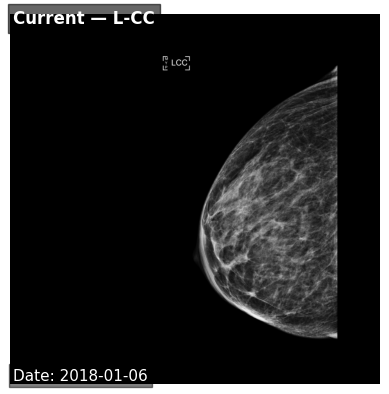

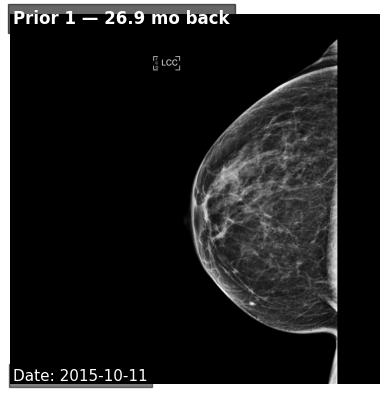

In [6]:
# Testing
# load current/priors CSV and visualize 

import math
from datetime import datetime

# Read and parse the manifest
m = pd.read_csv("temporalSequences.csv")
for c in ["prior_paths","prior_dates","prior_gaps_months","prior_accs"]:
    m[c] = m[c].apply(lambda x: json.loads(x) if isinstance(x, str) and x.startswith('[') else [])

row = m[m["num_priors"] > 0].iloc[0]

# Load images
cur_img, _ = load_dicom_image(row["current_path"], s3_client=s3)
pri_imgs  = [load_dicom_image(p, s3_client=s3)[0] for p in row["prior_paths"][:3]]
pri_dates = row["prior_dates"][:3]
pri_gaps  = row["prior_gaps_months"][:3]

def annotate_and_show(img, label_top_left, label_bottom_left=None):
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    # top-left label
    plt.text(
        8, 24, label_top_left,
        color='white', fontsize=12, weight='bold',
        bbox=dict(facecolor='black', alpha=0.6, pad=4)
    )
    # bottom-left label 
    if label_bottom_left:
        h = img.shape[0]
        plt.text(
            8, h - 12, label_bottom_left,
            color='white', fontsize=11,
            bbox=dict(facecolor='black', alpha=0.5, pad=3)
        )
    plt.show()

# Current image label
cur_date = row.get("current_date", None)
cur_date_str = f"Date: {cur_date}" if isinstance(cur_date, str) else ""
annotate_and_show(
    cur_img,
    label_top_left=f"Current — {row['ImageLateralityFinal']}-{row['ViewPosition']}",
    label_bottom_left=cur_date_str
)

# Priors with gap/months info
for i, (im, dt, gap) in enumerate(zip(pri_imgs, pri_dates, pri_gaps), 1):
    gap_str = f"{float(gap):.1f} mo back" if (gap is not None and not (isinstance(gap, float) and math.isnan(gap))) else "gap N/A"
    date_str = f"Date: {dt}" if isinstance(dt, str) else ""
    annotate_and_show(
        im,
        label_top_left=f"Prior {i} — {gap_str}",
        label_bottom_left=date_str
    )


## 5. Breast Segmentation

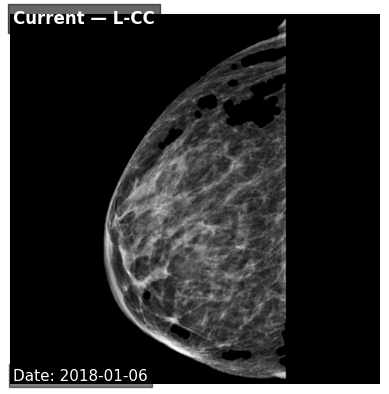

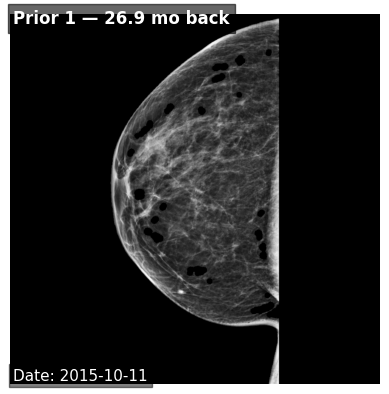

In [7]:
from skimage.morphology import binary_closing, remove_small_objects, disk
from skimage.measure import label, regionprops

#Create binary mask (1 = breast tissue, 0 = background) from normalized mammogram 
def breast_mask(img01, min_area_prop=0.05):
    #Convert to 8 bit grayscale image
    u8 = (img01*255).astype(np.uint8)
    #Smooth small bright/dark specks to make next threshold more stable
    u8 = cv2.GaussianBlur(u8, (5,5), 0)
    # finds the pixel intensity that best separates foreground vs background
    _, th = cv2.threshold(u8, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    # bw is binary image where 1 is breast tissue and 0 is background
    bw = (th > 0)

    # keep largest connected component (assuming it is breast). 
    # remove stray blobs and ensure mask covers main anatomy 
    lab = label(bw)
    if lab.max() == 0:
        return np.zeros_like(bw, np.uint8)
    regions = sorted(regionprops(lab), key=lambda r: r.area, reverse=True)
    m = (lab == regions[0].label)

    # morphology cleanup + remove tiny components
    # clean, contiguous mask covering the breast
    m = binary_closing(m, disk(7))
    min_area = int(min_area_prop * img01.shape[0] * img01.shape[1])
    m = remove_small_objects(m, min_size=min_area)
    #return binary mask 
    return m.astype(np.uint8)

# crop tightly around the breast region then resize/pad to a consistent square.
def crop_to_mask(img01, mask, pad=10, target=1024):
    #Find bounding box of all breast pixels (nonzero mask)
    #Add small padding of 10x to avoid cropping too close to edge
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return img01, mask
    y0, y1 = max(0, ys.min()-pad), min(img01.shape[0], ys.max()+pad+1)
    x0, x1 = max(0, xs.min()-pad), min(img01.shape[1], xs.max()+pad+1)
    #Crop image and mask 
    img = img01[y0:y1, x0:x1]
    msk = mask[y0:y1, x0:x1]

    # resize/pad to 1664 x 2048
    target_h = 1664
    target_w = 2048

    h, w = img.shape
    if (h, w) != (target_h, target_w):
        scale = min(target_h / h, target_w / w)
        nh, nw = int(round(h * scale)), int(round(w * scale))

        interp = cv2.INTER_AREA if scale < 1.0 else cv2.INTER_LINEAR
        img = cv2.resize(img, (nw, nh), interpolation=interp)
        msk = cv2.resize(msk.astype(np.uint8), (nw, nh), interpolation=cv2.INTER_NEAREST)

        pt = (target_h - nh) // 2
        pb = target_h - nh - pt
        pl = (target_w - nw) // 2
        pr = target_w - nw - pl

        img = np.pad(img, ((pt, pb), (pl, pr)), mode="constant", constant_values=0)
        msk = np.pad(msk, ((pt, pb), (pl, pr)), mode="constant", constant_values=0)

    return img, msk

cur_img, _ = load_dicom_image(row["current_path"], s3_client=s3)
cur_m = breast_mask(cur_img)
cur_img, cur_m = crop_to_mask(cur_img, cur_m)

pri_out = []
for p in row["prior_paths"][:3]:
    im, _ = load_dicom_image(p, s3_client=s3)
    m = breast_mask(im)
    im, m = crop_to_mask(im, m)
    pri_out.append((im, m))

# visualize 
cur_date = row.get("current_date", None)
cur_date_str = f"Date: {cur_date}" if isinstance(cur_date, str) else ""
# visualize current
annotate_and_show(
    cur_img * cur_m,                                    
    label_top_left=f"Current — {row['ImageLateralityFinal']}-{row['ViewPosition']}",
    label_bottom_left=(f"Date: {row.get('current_date')}" if isinstance(row.get('current_date'), str) else "")
)

# visualize priors (segmented)
for i, ((im, m), dt, gap) in enumerate(zip(pri_out, pri_dates, pri_gaps), 1):
    gap_str = f"{float(gap):.1f} mo back" if (gap is not None and not (isinstance(gap, float) and math.isnan(gap))) else "gap N/A"
    date_str = f"Date: {dt}" if isinstance(dt, str) else ""
    annotate_and_show(
        im * m,                                        
        label_top_left=f"Prior {i} — {gap_str}",
        label_bottom_left=date_str
    )


